In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# 1. Load the dataset from Phase 2
df = pd.read_csv('financial_inclusion_data.csv')

In [4]:
# 2. Feature Engineering: The Volatility Index 
# We'll simulate a 'Volatility' score based on existing Airtime Consistency. 
# Lower consistency = Higher Volatility (Proxy for erratic financial behavior).
df['Volatility_Index'] = (1 - df['Airtime_Consistency_Score']) * 10

In [5]:
# 3. Quick Statistical Check
print("--- Dataset Summary ---")
print(df.describe())

--- Dataset Summary ---
       Applicant_ID  Sim_Tenure_Months  Airtime_Consistency_Score  \
count   10000.00000       10000.000000               10000.000000   
mean     6000.50000          59.817000                   0.546518   
std      2886.89568          34.421627                   0.259649   
min      1001.00000           1.000000                   0.100048   
25%      3500.75000          30.000000                   0.320877   
50%      6000.50000          59.000000                   0.542508   
75%      8500.25000          90.000000                   0.773593   
max     11000.00000         119.000000                   0.999825   

       Avg_Wallet_Inflow  Electricity_Payment_Gap_Days  Data_Voice_Ratio  \
count       10000.000000                  10000.000000      10000.000000   
mean         4527.382361                     24.419300          2.742455   
std          1498.812996                     11.592555          1.302474   
min           500.000000                      5.00

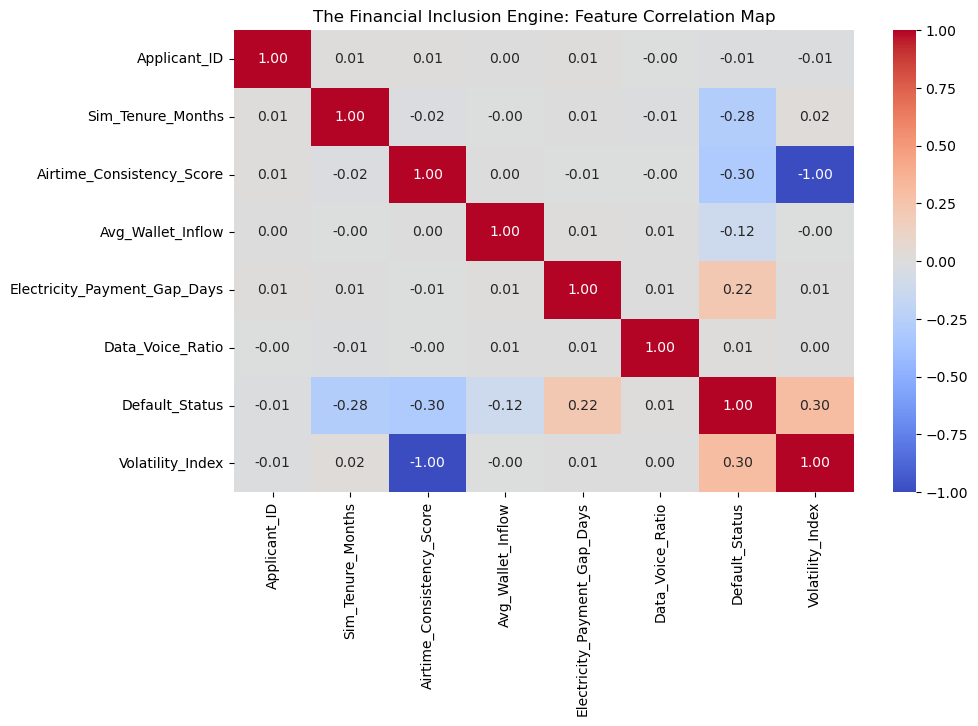

In [6]:
# 4. Correlation Analysis: Do our Pillars matter? [cite: 48, 51]
plt.figure(figsize=(10, 6))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('The Financial Inclusion Engine: Feature Correlation Map')
plt.show()

Negative Correlation with Risk: 
- Sim_Tenure_Months, Airtime_Consistency_Score, and Avg_Wallet_Inflow show negative correlations with Default_Status.

Interpretation: 
- As these scores go UP, the probability of default goes DOWN. 
- This validates your Stability, Consistency, and Velocity pillars.

Positive Correlation with Risk:
- Electricity_Payment_Gap_Days and your new Volatility_Index show positive correlations with Default_Status.

Interpretation:
- As these gaps or volatility scores increase, risk increases. This validates your Discipline pillar.

C:\Users\bpmog\AppData\Local\Temp\ipykernel_7292\1789877126.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Default_Status', y='Sim_Tenure_Months', data=df, palette='viridis')


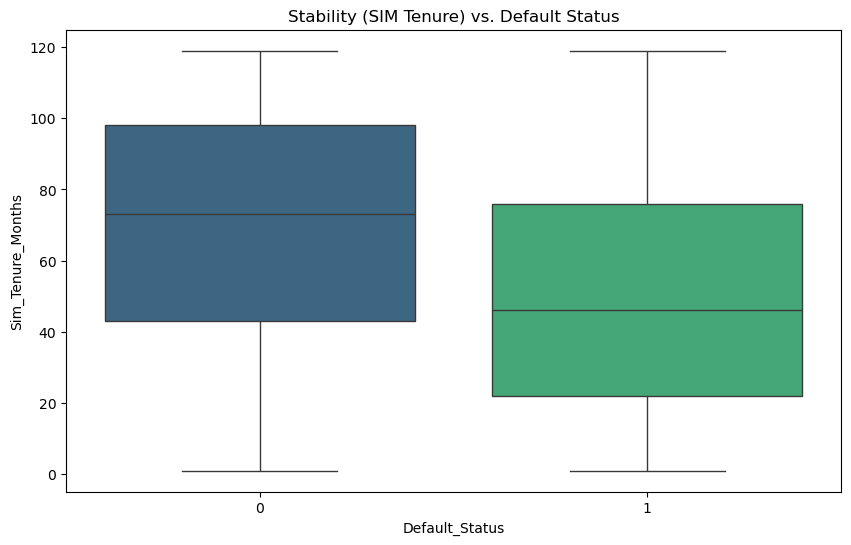

In [7]:
# 5. Visualizing the 'Credit Invisible' Gap
# Comparing Good Payers (0) vs Defaults (1) across SIM Tenure 
plt.figure(figsize=(10, 6))
sns.boxplot(x='Default_Status', y='Sim_Tenure_Months', data=df, palette='viridis')
plt.title('Stability (SIM Tenure) vs. Default Status')
plt.show()

The Findings:
- The median Sim_Tenure_Months for Good Payers (0) is visibly higher than for those who Defaulted (1).


In [8]:
# 6. Saving the Enhanced Dataset for Tableau
df.to_csv('financial_inclusion_eda_final.csv', index=False)
print("✅ Phase 3 Success! 'financial_inclusion_eda_final.csv' created with Volatility Index.")

✅ Phase 3 Success! 'financial_inclusion_eda_final.csv' created with Volatility Index.
